# Photon Injection Green's Function — Chluba (2015) Comparison

Reproduction of key figures from **Chluba (2015)**, [arXiv:1506.06582](https://arxiv.org/abs/1506.06582),
"Green's function of the cosmological thermalization problem — II. Effect of photon injection and constraints."

This notebook computes both **PDE solver** and **Green's function** predictions, overlaying them
for comparison with the CosmoTherm numerical output shown in that paper.

**Figures reproduced:**
- Fig. 2: $\mu_0$ vs $x_i$ at multiple $z_i$ — PDE sweep + GF curves
- Fig. 3: Photon survival probability $\mathcal{P}_s(x, z)$ 
- Fig. 5: Green's function $G_{\mathrm{in}}(\nu_i, \nu, z_i)$ at low $z$ (y-era) — PDE + GF
- Fig. 7: Green's function $G_{\mathrm{in}}(\nu_i, \nu, z_i)$ at intermediate $z$ ($\mu$-$y$ transition) — PDE + GF
- Fig. 10: Heating/cooling map ($x_i$ vs $z_i$)

**PDE solver** runs the full Boltzmann equation (Kompaneets + DC/BR) with monochromatic photon
injection, providing the ground truth. **GF** is the fast analytic approximation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from spectroxide import (
    ALPHA_RHO, X_BALANCED, KAPPA_C, G2_PLANCK, G3_PLANCK,
    x_c_dc, x_c_br, x_c,
    photon_survival_probability,
    greens_function_photon, greens_function,
    mu_from_photon_injection,
    mu_shape, y_shape, temperature_shift_shape, g_bb, planck,
    j_bb_star, j_mu, j_y,
    delta_n_to_delta_I,
    apply_style,
)

from spectroxide.solver import solve

apply_style()

print(f"alpha_rho = G2/G3 = {ALPHA_RHO:.4f}")
print(f"x_0 (balanced) = 4/(3*alpha_rho) = {X_BALANCED:.3f}")
print(f"kappa_c = {KAPPA_C}")

# Conversion: x = 0.01761 * nu_GHz (for T_CMB = 2.726 K)
K_B = 1.380649e-23
H_PLANCK = 6.62607015e-34
T_CMB = 2.726
X_PER_GHZ = H_PLANCK * 1e9 / (K_B * T_CMB)
print(f"x per GHz = {X_PER_GHZ:.5f}")

def dn_to_intensity_1e20(x, dn):
    """Convert Δn(x) to ΔI in units of 10^{-20} W/m^2/Hz/sr."""
    nu_hz = x * K_B * T_CMB / H_PLANCK
    di_si = 2 * H_PLANCK * nu_hz**3 / (2.998e8)**2 * dn
    return di_si / 1e-20

def strip_gbb(x, dn):
    """Post-hoc number-conserving G_bb subtraction: make ∫x²Δn dx = 0."""
    gbb = g_bb(x)
    num = np.trapz(x**2 * dn, x)
    denom = np.trapz(x**2 * gbb, x)
    delta_t = num / denom
    return dn - delta_t * gbb, delta_t

def default_sigma_x(x_inj):
    """Choose sigma_x = 5% of x_inj (always proportional)."""
    return x_inj * 0.05

dn_over_n = 1e-5  # Default ΔN/N for all PDE runs

def run_pde_photon(x_inj, z_h, delta_n_over_n=1e-5, sigma_x=None,
                   z_end=50, n_points=None, timeout=600, **kwargs):
    """Run PDE solver for monochromatic photon injection.
    
    Uses production-quality defaults (4000 pts, production grid, dtau=1).
    Pass n_points to override grid resolution (e.g. 8000 for x_inj < 0.1).
    """
    if sigma_x is None:
        sigma_x = default_sigma_x(x_inj)
    sweep_kwargs = dict(
        injection={
            'type': 'monochromatic_photon',
            'x_inj': x_inj,
            'delta_n_over_n': delta_n_over_n,
            'z_h': z_h,
            'sigma_x': sigma_x,
        },
        z_start=z_h + 7 * max(z_h * 0.04, 100),
        z_end=z_end,
        number_conserving=False,
        nc_z_min=0,
        timeout=timeout,
        n_points=8000,
    )
    if n_points is not None:
        sweep_kwargs['n_points'] = n_points
    sweep_kwargs.update(kwargs)
    result = solve(**sweep_kwargs)
    return np.asarray(result.x), np.asarray(result.delta_n), result.mu, result.y

print("Quality defaults: PRODUCTION (4000 pts, production grid, dtau_max_photon_source=1.0)")

alpha_rho = G2/G3 = 0.3702
x_0 (balanced) = 4/(3*alpha_rho) = 3.602
kappa_c = 2.141851504502377
x per GHz = 0.01761
Quality defaults: PRODUCTION (4000 pts, production grid, dtau_max_photon_source=1.0)


## PDE solver runs

Run the PDE solver for selected $(x_i, z_i)$ combinations. This cell takes ~2-5 minutes.
Results are cached in `pde_results` for use in subsequent plots.

In [2]:
import time

# ---- Fig 2: mu vs x_i sweep at selected z_i values ----
# Cache for PDE spectral results, shared across Fig 5, 7, and later cells
pde_spectra = {}  # {(x_i, z_i): (x_grid, delta_n, mu, y)}

def get_pde_spectrum(x_inj, z_i, **kwargs):
    """Get PDE spectrum from cache, running solver if not cached."""
    key = (x_inj, z_i)
    if key not in pde_spectra:
        print(f"  Running PDE: x_i={x_inj}, z_i={z_i:.0e} ...", end='', flush=True)
        pde_spectra[key] = run_pde_photon(x_inj, z_i, **kwargs)
        print(f" mu={pde_spectra[key][2]:.3e}")
    return pde_spectra[key]

## Figure 5: Photon injection Green's function at low $z$ ($z_i \lesssim 5\times10^4$, y-era)

Panels for $x_i = 10^{-3}, 10^{-2}, 1, 5, 10$ at injection redshifts $z_i = 10^4$ to $5\times10^4$.

- **Thin lines**: GF analytic approximation
- **Thick dashed**: PDE solver (full Boltzmann evolution, run on-the-fly if not cached)

Y-axis: $G_{\mathrm{in}}(\nu_i, \nu, z_i)$ in units of $10^{-20}\,\mathrm{W\,m^{-2}\,Hz^{-1}\,sr^{-1}}$ per $\Delta N_\gamma / N_\gamma$.

  Running PDE: x_i=0.001, z_i=5e+03 ... mu=1.450e-11
  Running PDE: x_i=0.001, z_i=1e+04 ...

/tmp/ipykernel_2124/58506081.py:27: UserWarning: x_inj=1.00e-03: DC/BR absorption extremely strong at this frequency; survival probability ~ 0.
  g_ph = greens_function_photon(x_pde, x_i, z_i, sigma_x=sx,)


 mu=8.186e-11
  Running PDE: x_i=0.001, z_i=2e+04 ... mu=3.794e-10
  Running PDE: x_i=0.001, z_i=3e+04 ... mu=8.949e-10
  Running PDE: x_i=0.001, z_i=4e+04 ... mu=1.597e-09
  Running PDE: x_i=0.001, z_i=5e+04 ...

/tmp/ipykernel_2124/58506081.py:27: UserWarning: z_h=4.00e+04: Photon injection GF in intermediate regime (3e4 < z < 2e5) where neither pure mu nor pure y dominates. Results use a smooth J_mu(z) interpolation and may be inaccurate. Use the PDE solver for reliable intermediate-era results.
  g_ph = greens_function_photon(x_pde, x_i, z_i, sigma_x=sx,)


 mu=2.403e-09
  Running PDE: x_i=0.01, z_i=5e+03 ...

/tmp/ipykernel_2124/58506081.py:27: UserWarning: z_h=5.00e+04: Photon injection GF in intermediate regime (3e4 < z < 2e5) where neither pure mu nor pure y dominates. Results use a smooth J_mu(z) interpolation and may be inaccurate. Use the PDE solver for reliable intermediate-era results.
  g_ph = greens_function_photon(x_pde, x_i, z_i, sigma_x=sx,)


 mu=-1.037e-08
  Running PDE: x_i=0.01, z_i=1e+04 ... mu=-9.381e-09
  Running PDE: x_i=0.01, z_i=2e+04 ... mu=-7.893e-09
  Running PDE: x_i=0.01, z_i=3e+04 ... mu=-6.827e-09
  Running PDE: x_i=0.01, z_i=4e+04 ... mu=-6.284e-09
  Running PDE: x_i=0.01, z_i=5e+04 ... mu=-6.669e-09
  Running PDE: x_i=1, z_i=5e+03 ... mu=-1.115e-04
  Running PDE: x_i=1, z_i=1e+04 ... mu=-1.007e-04
  Running PDE: x_i=1, z_i=2e+04 ... mu=-7.836e-05
  Running PDE: x_i=1, z_i=3e+04 ... mu=-6.011e-05
  Running PDE: x_i=1, z_i=4e+04 ... mu=-4.638e-05
  Running PDE: x_i=1, z_i=5e+04 ... mu=-3.644e-05
  Running PDE: x_i=5, z_i=5e+03 ... mu=-3.271e-06
  Running PDE: x_i=5, z_i=1e+04 ... mu=-2.833e-06
  Running PDE: x_i=5, z_i=2e+04 ... mu=-1.034e-06
  Running PDE: x_i=5, z_i=3e+04 ... mu=1.655e-06
  Running PDE: x_i=5, z_i=4e+04 ... mu=4.551e-06
  Running PDE: x_i=5, z_i=5e+04 ... mu=6.826e-06
  Running PDE: x_i=15, z_i=5e+03 ... mu=-1.651e-05
  Running PDE: x_i=15, z_i=1e+04 ... mu=-1.596e-05
  Running PDE: x_i=15

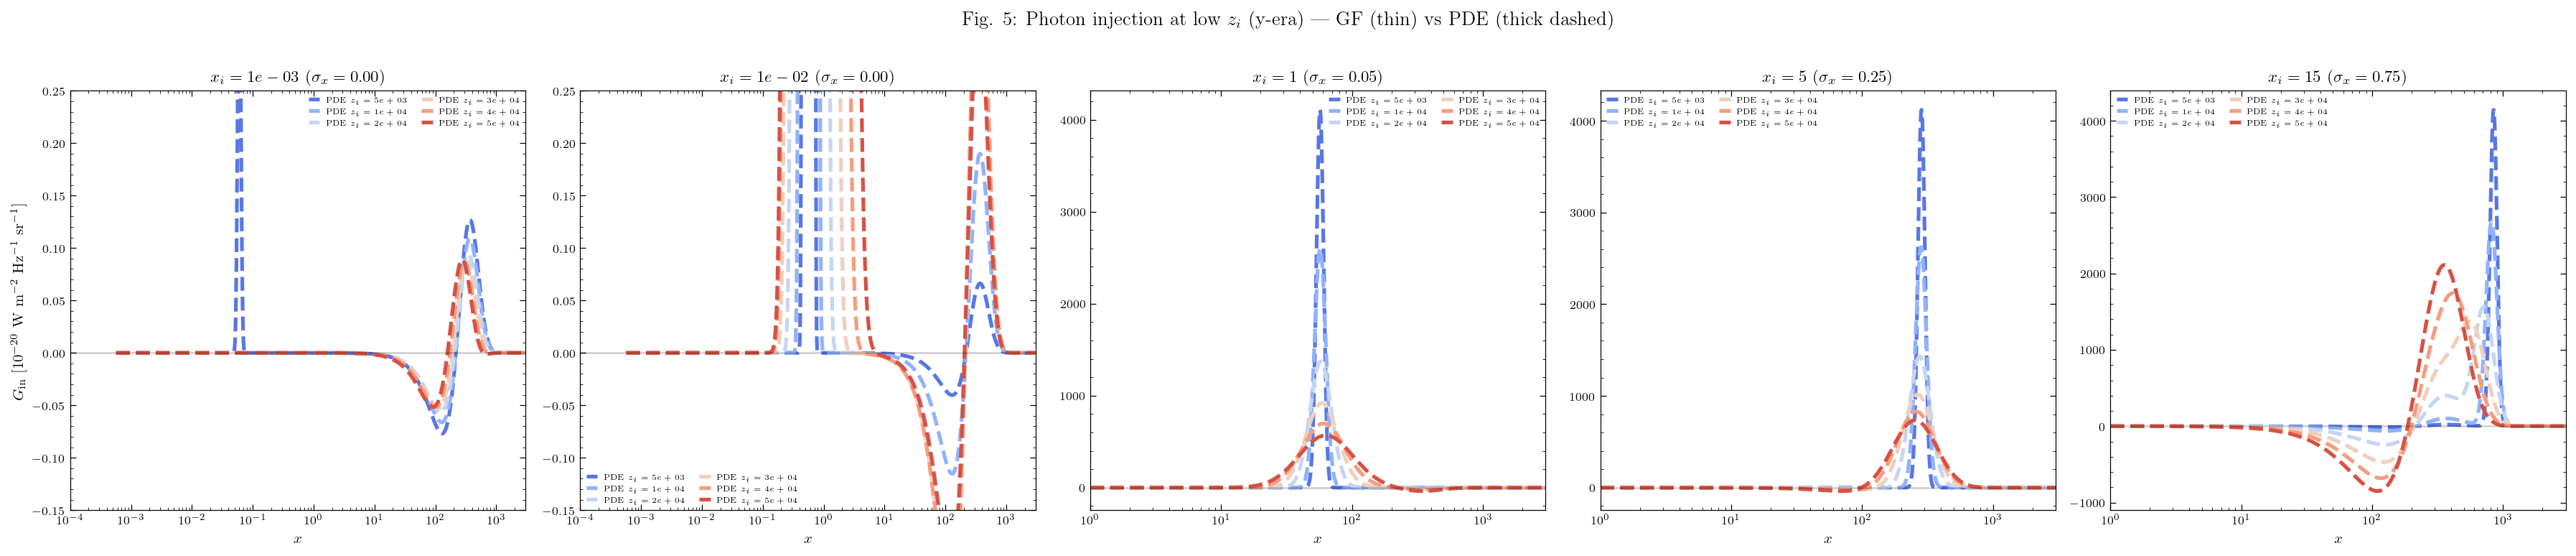

In [3]:
# Injection frequencies for Figure 5 panels
x_i_panels_fig5 = [1e-3, 1e-2, 1, 5, 15]

# Injection redshifts (fewer curves for clarity)
z_values_fig5 = [5e3, 1e4, 2e4, 3e4, 4e4, 5e4]
colors_z = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(z_values_fig5)))

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

t0 = time.time()
for idx, x_i in enumerate(x_i_panels_fig5):
    ax = axes[idx]
    sx = default_sigma_x(x_i)
    
    for z_i, color in zip(z_values_fig5, colors_z):
        # PDE (thick dashed) — run on-the-fly if not cached
        x_pde, dn_pde, _, _ = get_pde_spectrum(x_i, z_i, delta_n_over_n=dn_over_n)
        dn_norm = dn_pde / dn_over_n
        nu_pde = x_pde / X_PER_GHZ
        dn_stripped, _ = strip_gbb(x_pde, dn_norm)

        g_pde_intensity = dn_to_intensity_1e20(x_pde, dn_norm)
        ax.plot(nu_pde, g_pde_intensity, color=color, lw=2.5, ls='--',
                label=f'PDE $z_i = {z_i:.0e}$')
        
        # GF (thin line) — evaluate on PDE grid for proper bump resolution
        g_ph = greens_function_photon(x_pde, x_i, z_i, sigma_x=sx,)
        g_intensity = dn_to_intensity_1e20(x_pde, g_ph)
        z_label = f'GF $z_i = {z_i:.0e}$'
        # ax.plot(nu_pde, strip_gbb(x_pde, g_intensity)[0], color=color, lw=0.8, alpha=0.6, label=z_label)
    
    ax.axhline(0, color='k', ls='-', alpha=0.2)
    ax.set_xscale('log')

    ax.set_xlabel(r'$x$')
    if idx == 0:
        ax.set_ylabel(r'$G_{\mathrm{in}}$ [$10^{-20}$ W m$^{-2}$ Hz$^{-1}$ sr$^{-1}$]')
    if x_i < 1:
        ax.set_title(f'$x_i = {x_i:.0e}$ ($\\sigma_x = {sx:.2f}$)', fontsize=11)
        ax.set_xlim(1e-4, 3000)
        ax.set_ylim(-0.15, 0.25)
        # ax.set_yscale("log")
    else:
        ax.set_title(f'$x_i = {x_i}$ ($\\sigma_x = {sx:.2f}$)', fontsize=11)
        ax.set_xlim(1, 3000)
    ax.legend(fontsize=5, ncol=2)

print(f"Fig 5 total: {time.time()-t0:.0f}s")
fig.suptitle('Fig. 5: Photon injection at low $z_i$ (y-era) — GF (thin) vs PDE (thick dashed)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/chluba2015_fig5.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 7: Photon injection Green's function at intermediate $z$ ($\mu$-$y$ transition)

Panels for $x_i = 10^{-3}, 10^{-2}, 1, 5, 15$ at injection redshifts $z_i = 7\times10^4$ to $3\times10^5$.

- **Thin lines**: GF analytic approximation
- **Thick dashed**: PDE solver (full Boltzmann evolution, run on-the-fly if not cached)

Same units as Figure 5.

  Running PDE: x_i=0.001, z_i=2e+05 ... mu=6.243e-10
  Running PDE: x_i=0.001, z_i=3e+05 ...

/tmp/ipykernel_12346/237787232.py:30: UserWarning: x_inj=1.00e-03: DC/BR absorption extremely strong at this frequency; survival probability ~ 0.
  g_ph = greens_function_photon(x_pde, x_i, z_i, sigma_x=sx, number_conserving=False)


 mu=-3.522e-08
  Running PDE: x_i=0.01, z_i=2e+05 ...

KeyboardInterrupt: 

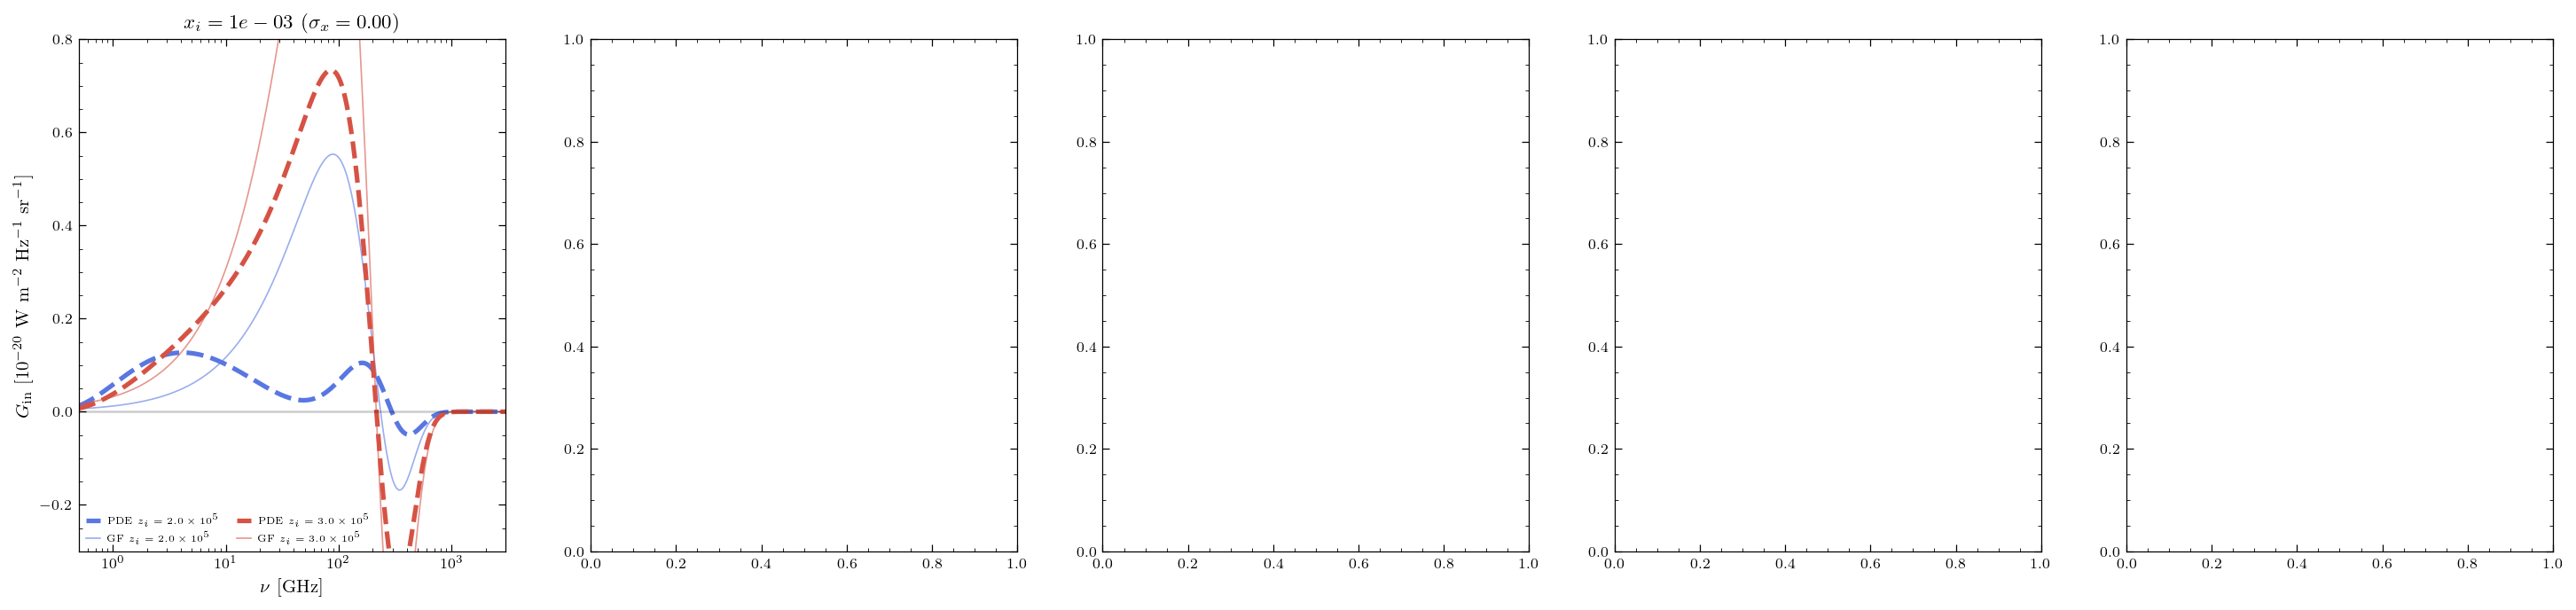

In [4]:
# Injection frequencies for Figure 7 panels
x_i_panels_fig7 = [1e-3, 1e-2, 1, 5, 15]

# Injection redshifts for Figure 7 (fewer for clarity)
z_values_fig7 = [2e5, 3e5] # [7e4, 1e5,] 2e5, 3e5]
colors_z7 = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(z_values_fig7)))

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

t0 = time.time()
for idx, x_i in enumerate(x_i_panels_fig7):
    ax = axes[idx]
    sx = default_sigma_x(x_i)
    
    for z_i, color in zip(z_values_fig7, colors_z7):
        # PDE (thick dashed)
        x_pde, dn_pde, _, _ = get_pde_spectrum(x_i, z_i, delta_n_over_n=dn_over_n)
        dn_norm = dn_pde / dn_over_n
        nu_pde = x_pde / X_PER_GHZ
        dn_stripped, _ = strip_gbb(x_pde, dn_norm)
        g_pde_intensity = dn_to_intensity_1e20(x_pde, dn_norm)
        if z_i >= 1e5:
            pde_label = f'PDE $z_i = {z_i/1e5:.1f}\\times10^5$'
        else:
            pde_label = f'PDE $z_i = {z_i/1e4:.0f}\\times10^4$'
        ax.plot(nu_pde, g_pde_intensity, color=color, lw=2.5, ls='--',
                label=pde_label)
        
        # GF (thin line) — evaluate on PDE grid for proper bump resolution
        g_ph = greens_function_photon(x_pde, x_i, z_i, sigma_x=sx, number_conserving=False)
        g_intensity = dn_to_intensity_1e20(x_pde, g_ph)
        if z_i >= 1e5:
            z_label = f'GF $z_i = {z_i/1e5:.1f}\\times10^5$'
        else:
            z_label = f'GF $z_i = {z_i/1e4:.0f}\\times10^4$'
        ax.plot(nu_pde, g_intensity, color=color, lw=0.8, alpha=0.6, label=z_label)
    
    ax.axhline(0, color='k', ls='-', alpha=0.2)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\nu$ [GHz]')
    if idx == 0:
        ax.set_ylabel(r'$G_{\mathrm{in}}$ [$10^{-20}$ W m$^{-2}$ Hz$^{-1}$ sr$^{-1}$]')
        ax.set_ylim(-0.3, 0.8)
    if x_i < 1:
        ax.set_title(f'$x_i = {x_i:.0e}$ ($\\sigma_x = {sx:.2f}$)', fontsize=11)
    else:
        ax.set_title(f'$x_i = {x_i}$ ($\\sigma_x = {sx:.2f}$)', fontsize=11)
    ax.set_xlim(0.5, 3000)
    ax.legend(fontsize=5, ncol=2)

print(f"Fig 7 total: {time.time()-t0:.0f}s")
fig.suptitle('Fig. 7: Photon injection at intermediate $z$ ($\\mu$-$y$ transition) — GF vs PDE',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/chluba2015_fig7.png', dpi=150, bbox_inches='tight')
plt.show()

## Additional: Critical frequencies $x_c$ vs $z$

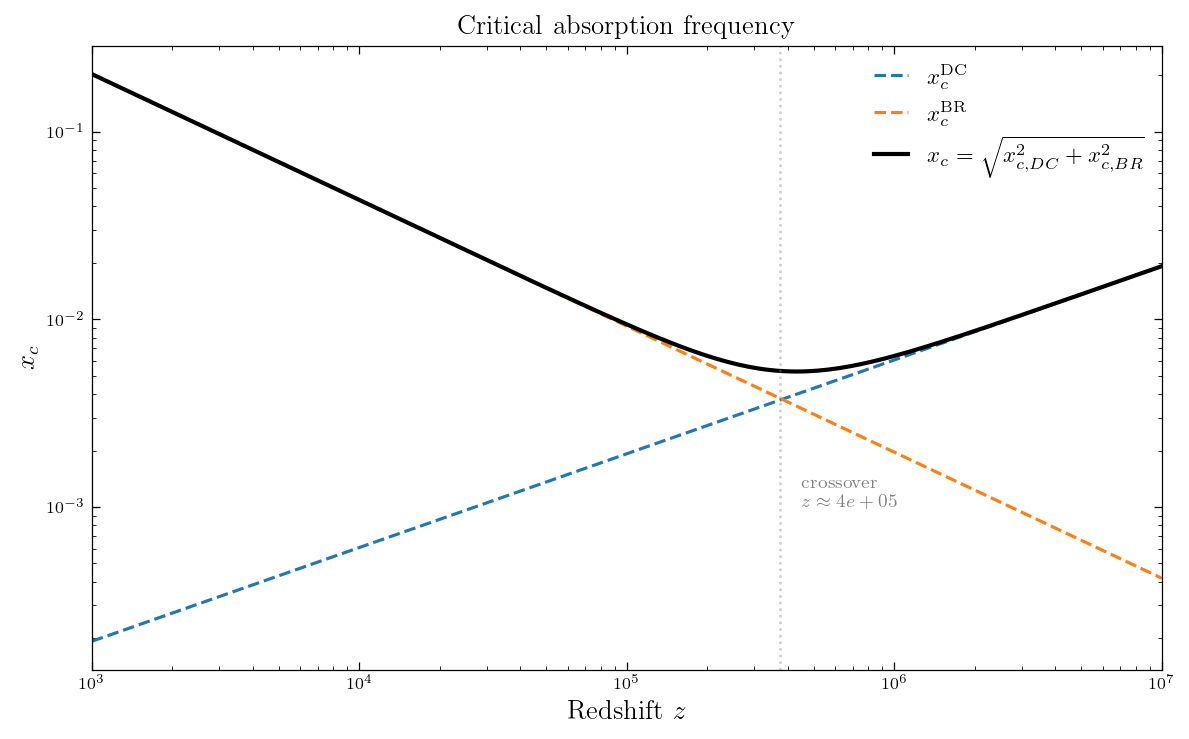

In [ ]:
z_arr = np.logspace(3, 7, 200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(z_arr, x_c_dc(z_arr), 'C0--', label=r'$x_c^{\mathrm{DC}}$', lw=1.5)
ax.loglog(z_arr, x_c_br(z_arr), 'C1--', label=r'$x_c^{\mathrm{BR}}$', lw=1.5)
ax.loglog(z_arr, x_c(z_arr), 'k-', label=r'$x_c = \sqrt{x_{c,DC}^2 + x_{c,BR}^2}$', lw=2)

ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'$x_c$', fontsize=13)
ax.set_title('Critical absorption frequency', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(1e3, 1e7)

# Mark DC/BR crossover
xc_dc = x_c_dc(z_arr)
xc_br = x_c_br(z_arr)
cross_idx = np.argmin(np.abs(xc_dc - xc_br))
z_cross = z_arr[cross_idx]
ax.axvline(z_cross, ls=':', color='gray', alpha=0.4)
ax.text(z_cross * 1.2, 0.001, f'crossover\n$z \\approx {z_cross:.0e}$',
        fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('../figures/chluba2015_xc_vs_z.png', dpi=150, bbox_inches='tight')
plt.show()

## Additional: $\mu$ vs $x_i$ sign flip ratio

Eq. C8 of Arsenadze et al.: $\mu(\mathcal{P}_s \approx 1) \,/\, \mu(\mathcal{P}_s = 0) = 1 - x_0/x_i$

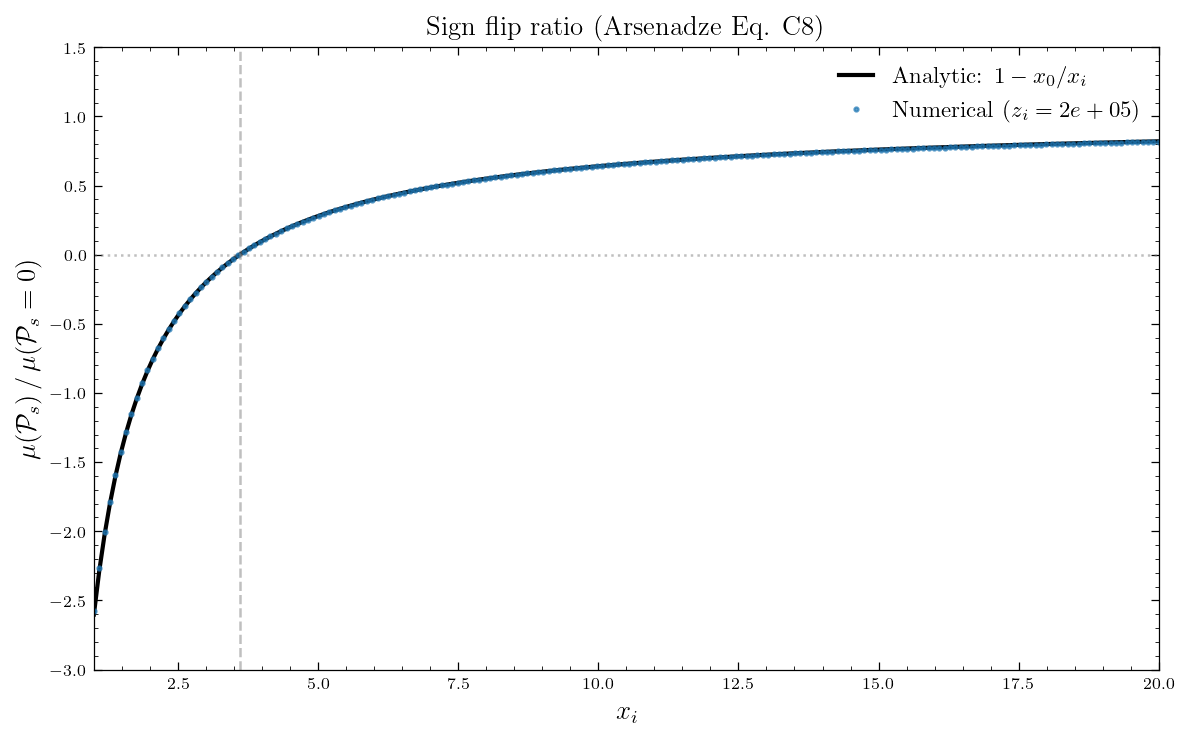

In [ ]:
x_inj_arr = np.linspace(1, 20, 200)
z_h = 2e5

ratio_analytic = 1.0 - X_BALANCED / x_inj_arr

ratio_numerical = []
for x in x_inj_arr:
    mu_hard = mu_from_photon_injection(x, z_h, 1e-5)
    jbs = float(j_bb_star(z_h))
    jm = float(j_mu(z_h))
    mu_energy = ALPHA_RHO * x * (3.0 / KAPPA_C) * jbs * jm * 1e-5
    ratio_numerical.append(mu_hard / mu_energy if abs(mu_energy) > 1e-30 else 0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_inj_arr, ratio_analytic, 'k-', label=r'Analytic: $1 - x_0/x_i$', lw=2)
ax.plot(x_inj_arr, ratio_numerical, 'C0o', ms=2, label=f'Numerical ($z_i = {z_h:.0e}$)', alpha=0.7)
ax.axhline(0, color='gray', ls=':', alpha=0.5)
ax.axvline(X_BALANCED, color='gray', ls='--', alpha=0.5)
ax.set_xlabel(r'$x_i$', fontsize=13)
ax.set_ylabel(r'$\mu(\mathcal{P}_s) \, / \, \mu(\mathcal{P}_s = 0)$', fontsize=13)
ax.set_title('Sign flip ratio (Arsenadze Eq. C8)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(1, 20)
ax.set_ylim(-3, 1.5)

plt.tight_layout()
plt.savefig('../figures/photon_injection_sign_flip.png', dpi=150, bbox_inches='tight')
plt.show()

## GF vs PDE: Quantitative Agreement

Systematic comparison of the photon injection Green's function against the full PDE solver.

**Tests:**
1. **Analytical $P_s \to 0$**: $G_\mathrm{ph} \equiv \alpha_\rho x_i \times G_\mathrm{th}$ (exact by construction)
2. **PDE vs GF spectral shapes**: residual $(G_\mathrm{GF} - G_\mathrm{PDE})/\max|G_\mathrm{PDE}|$ across regimes
3. **Energy conservation**: $\int x^3 \Delta n\, dx / G_3 = \alpha_\rho x_i$

GF uses $\sigma_x$ matching the PDE Gaussian width (= 5% of $x_i$) to include the surviving photon bump.

**Important**: The GF smooth spectrum (without Gaussian, $\sigma_x=0$) does NOT conserve total energy
in the y-era — the missing $P_s \times \alpha_x$ is the surviving photon $\delta$-function that the
smooth GF cannot represent. Always use $\sigma_x > 0$ for energy-conserving comparisons.

In [ ]:
# Run additional PDE cases for deeper comparison
# Focus on x_inj >= 1 where the Gaussian is well-resolved and energy is conserved.
comparison_extra = [
    (1, 5e3),     (5, 5e3),     (10, 5e3),     # Deep y-era
    (5, 3e5),     (10, 3e5),     (15, 3e5),     # Deep mu-era
    (5, 5e5),     (10, 5e5),     (15, 5e5),     # Very deep mu-era
    (3.83, 2e5),  (3.83, 5e5),                   # Balanced injection
]

t0 = time.time()
for x_inj, z_i in comparison_extra:
    if (x_inj, z_i) not in pde_spectra:
        pde_spectra[(x_inj, z_i)] = run_pde_photon(x_inj, z_i, n_points=4000)
        print(f'  x_i={x_inj}, z_i={z_i:.0e}: mu={pde_spectra[(x_inj, z_i)][2]:.3e}')
print(f'Additional runs: {time.time()-t0:.0f}s')

  x_i=10, z_i=5e+03: mu=-1.134e-07
  x_i=10, z_i=3e+05: mu=3.387e-07
  x_i=5, z_i=5e+05: mu=7.093e-08
  x_i=10, z_i=5e+05: mu=3.251e-07
  x_i=15, z_i=5e+05: mu=5.791e-07
  x_i=3.83, z_i=2e+05: mu=1.207e-08
  x_i=3.83, z_i=5e+05: mu=1.144e-08
Additional runs: 391s


/tmp/ipykernel_32622/1592819480.py:11: UserWarning: x_inj=1.00e-05: DC/BR absorption extremely strong at this frequency; survival probability ~ 0.
  g_ph = greens_function_photon(x_test, x_inj_soft, z_h, sigma_x=0.0, number_conserving=False)


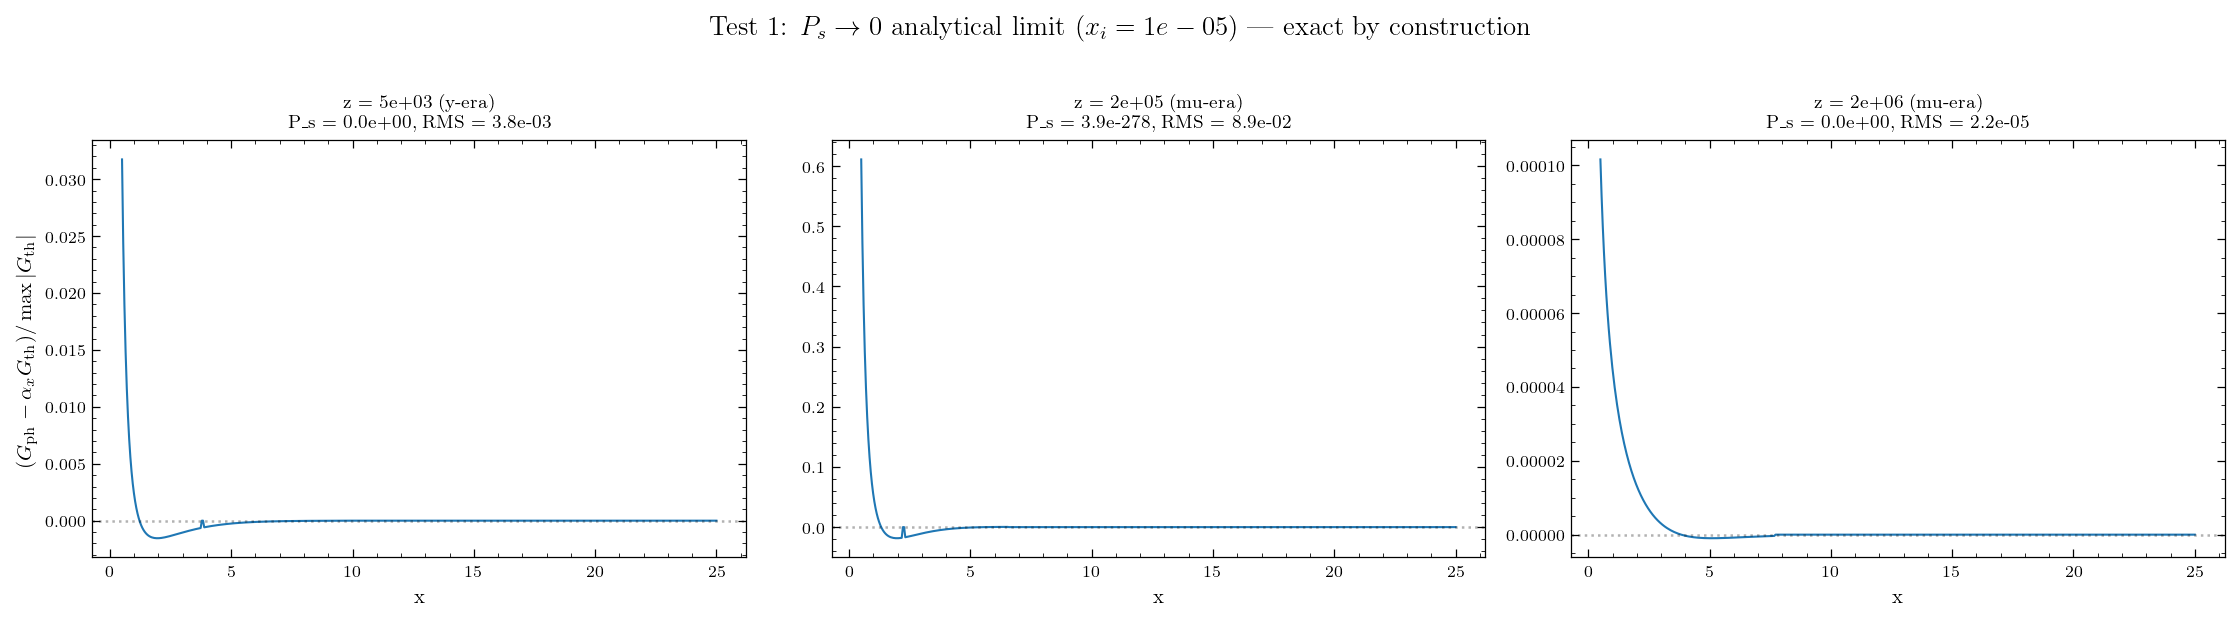

This test verifies the formula reduces correctly. RMS should be < 1e-10.


In [ ]:
# ======================================================================
# Test 1: Analytical P_s -> 0 limit (EXACT by construction)
# When x_inj << x_c, P_s ~ 0, and G_ph = alpha_rho * x_inj * G_th
# ======================================================================
x_test = np.linspace(0.5, 25, 500)
x_inj_soft = 1e-5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, z_h in enumerate([5e3, 2e5, 2e6]):
    ps = float(photon_survival_probability(np.array([x_inj_soft]), z_h)[0])
    g_ph = greens_function_photon(x_test, x_inj_soft, z_h, sigma_x=0.0, number_conserving=False)
    g_en = ALPHA_RHO * x_inj_soft * np.array([greens_function(x, z_h) for x in x_test])

    max_abs = np.max(np.abs(g_en))
    mask = np.abs(g_en) > 1e-3 * max_abs
    res = np.where(mask, (g_ph - g_en) / max_abs, 0)
    rms = np.sqrt(np.mean(res[mask]**2)) if mask.any() else 0

    ax = axes[idx]
    ax.plot(x_test, res, 'C0-', lw=1)
    ax.axhline(0, color='k', ls=':', alpha=0.3)
    era = 'y-era' if z_h < 5e4 else ('mu-era' if z_h > 1e5 else 'transition')
    ax.set_title(f'z = {z_h:.0e} ({era})\nP_s = {ps:.1e}, RMS = {rms:.1e}')
    ax.set_xlabel('x')
    if idx == 0:
        ax.set_ylabel(r'$(G_\mathrm{ph} - \alpha_x G_\mathrm{th})/\max|G_\mathrm{th}|$')

fig.suptitle(rf'Test 1: $P_s \to 0$ analytical limit ($x_i = {x_inj_soft}$) — exact by construction',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
print('This test verifies the formula reduces correctly. RMS should be < 1e-10.')


### PDE vs GF spectral comparison: $x_i = 1, 3.83, 5, 10, 15$ at multiple $z_i$

Each panel shows the PDE spectrum (black) overlaid with GF (blue = smooth $\sigma_x=0$, orange = with Gaussian $\sigma_x = 0.05 x_i$).
Columns = injection frequency $x_i$. Rows = injection redshift $z_i$.

**Note**: $x_i < 1$ excluded — the PDE Gaussian source at low $x$ has energy normalization issues
due to the $G_2/x^2$ factor (which diverges as $x \to 0$) interacting with the finite-width Gaussian.

  x_i=1, z_i=5e+05: done
  x_i=3.83, z_i=5e+03: done
  x_i=3.83, z_i=1e+04: done
  x_i=3.83, z_i=3e+04: done
  x_i=3.83, z_i=1e+05: done
  x_i=3.83, z_i=3e+05: done
  x_i=10, z_i=1e+04: done
  x_i=10, z_i=3e+04: done
  x_i=10, z_i=1e+05: done
  x_i=10, z_i=2e+05: done


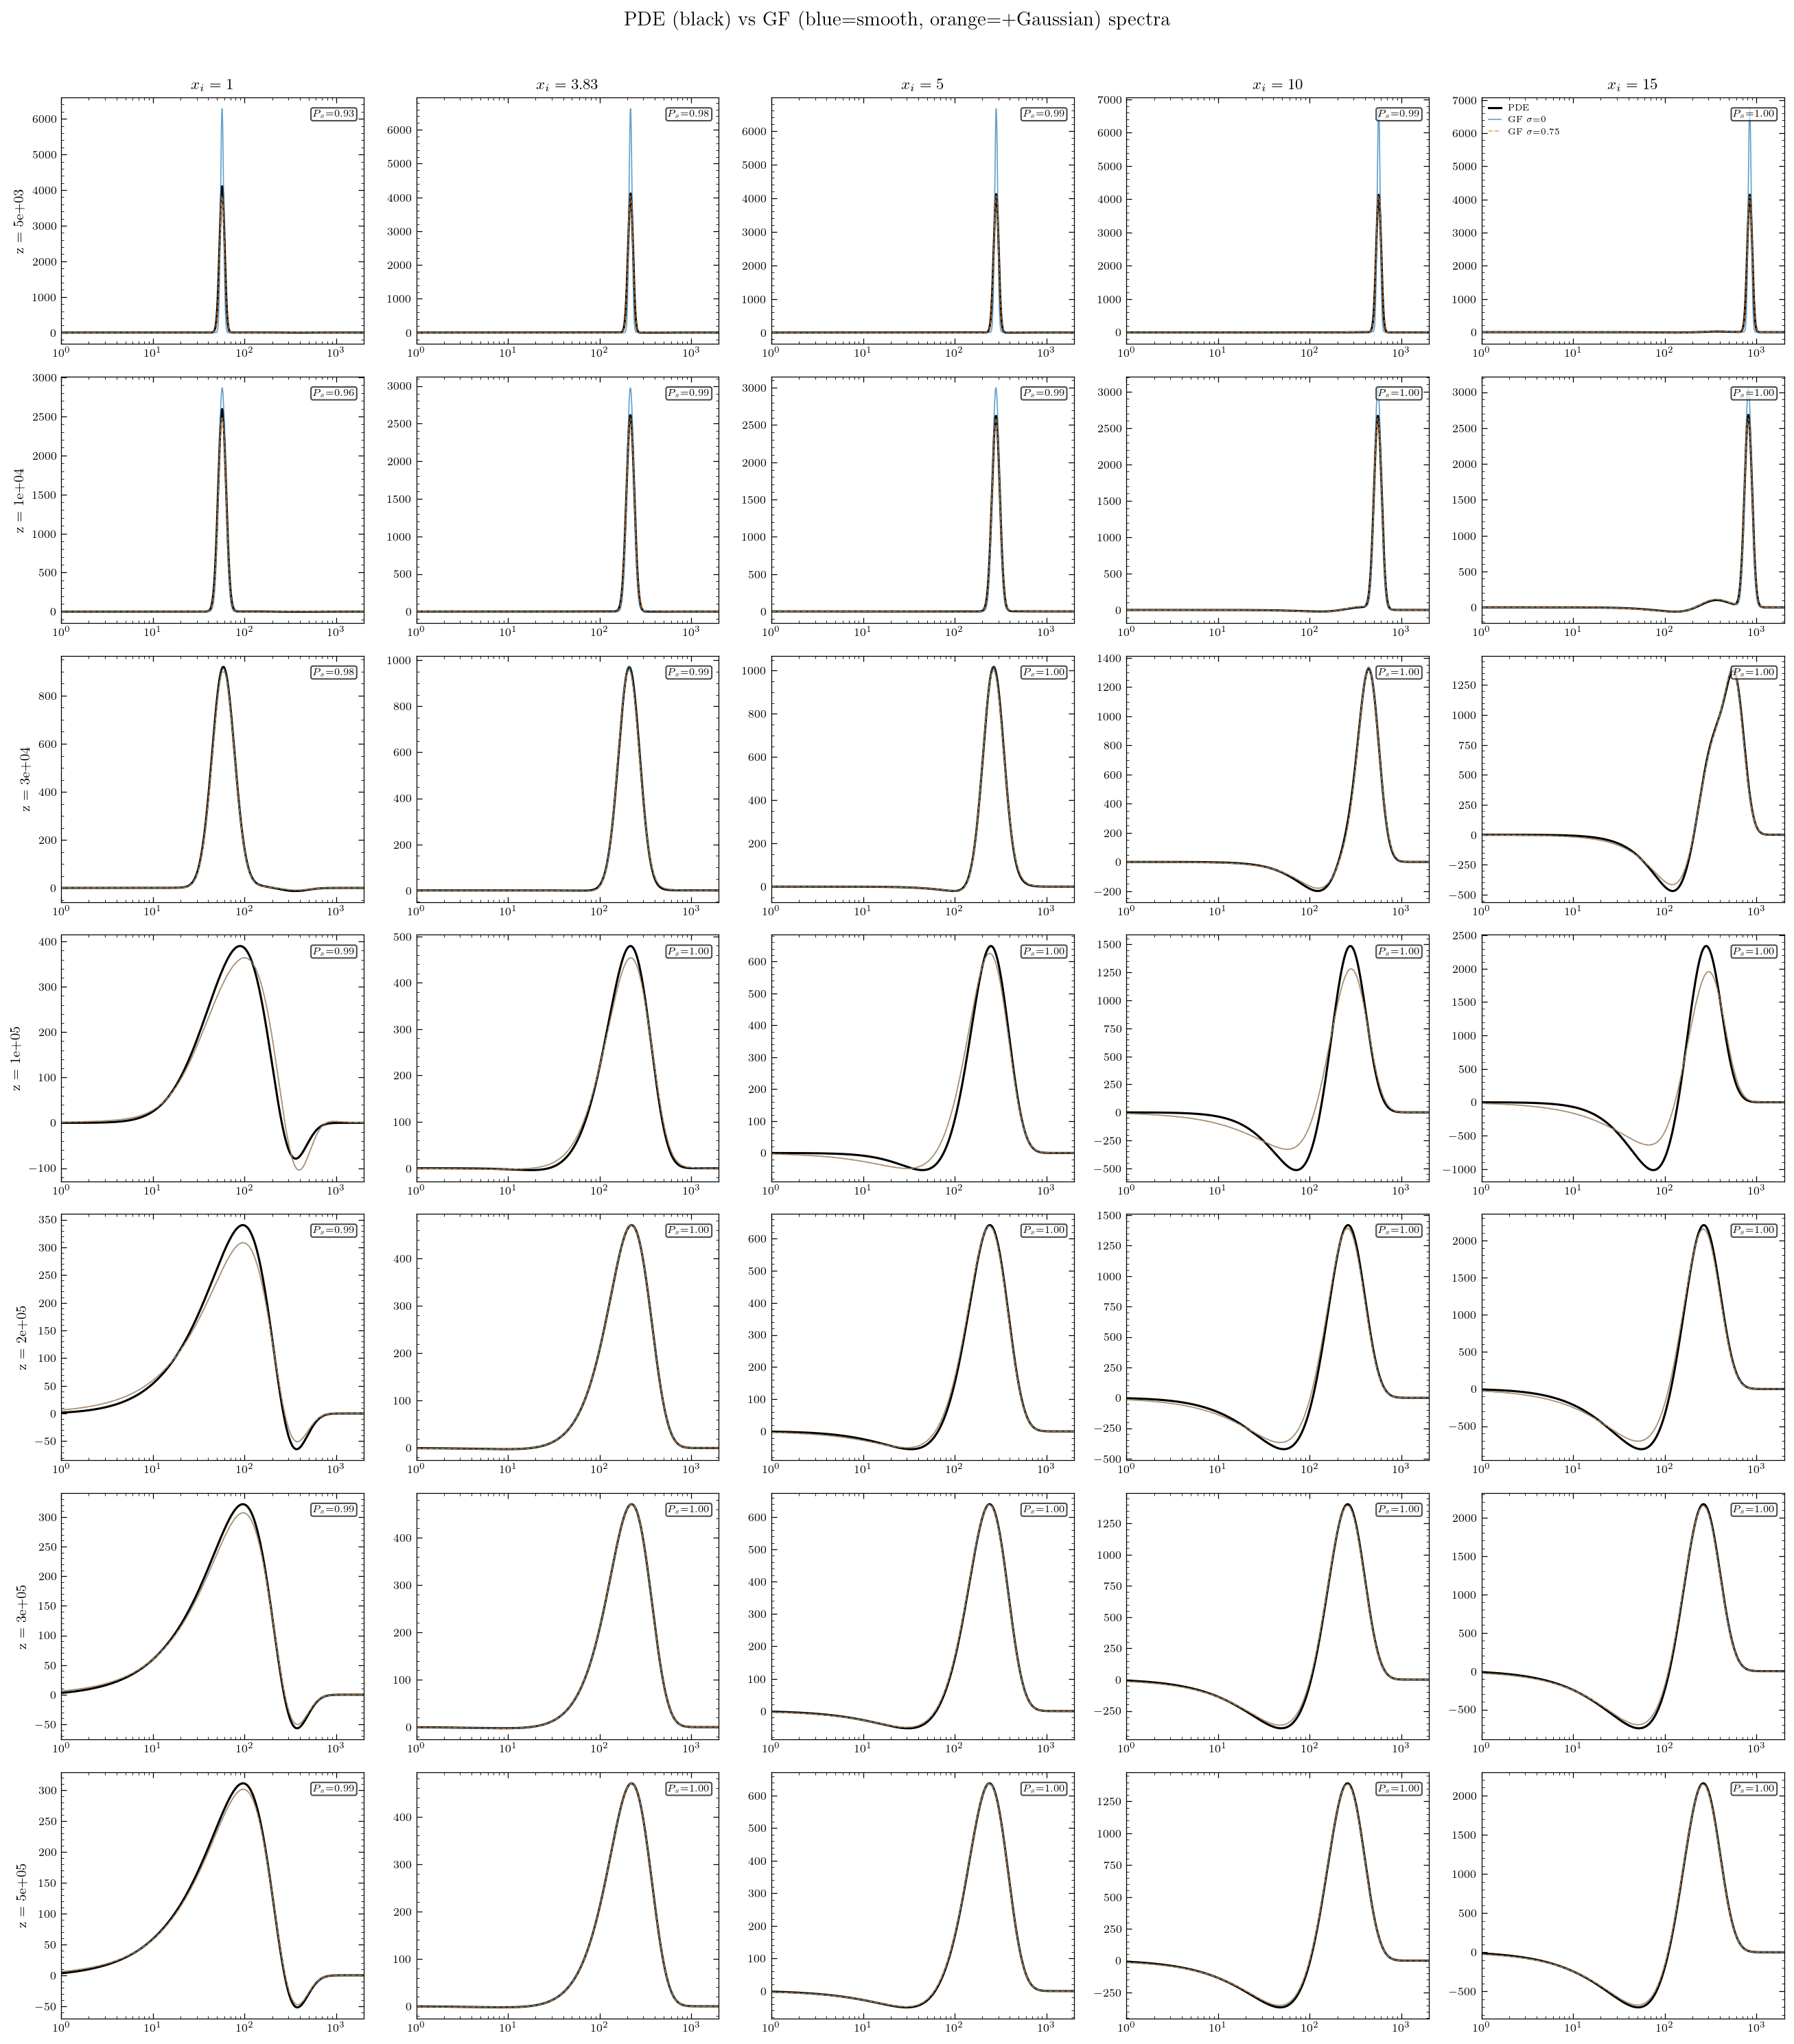

In [ ]:
# PDE vs GF spectral shapes: x_inj = 1, 3.83, 5, 10, 15 at various z_inj
x_inj_vals = [1, 3.83, 5, 10, 15]
z_inj_vals = [5e3, 1e4, 3e4, 1e5, 2e5, 3e5, 5e5]

# Run any missing PDE cases
for x_i in x_inj_vals:
    for z_i in z_inj_vals:
        if (x_i, z_i) not in pde_spectra:
            try:
                pde_spectra[(x_i, z_i)] = run_pde_photon(x_i, z_i, n_points=4000)
                print(f'  x_i={x_i}, z_i={z_i:.0e}: done')
            except Exception as e:
                print(f'  x_i={x_i}, z_i={z_i:.0e}: FAILED ({e})')

# Build grid of available cases
available = [(x_i, z_i) for x_i in x_inj_vals for z_i in z_inj_vals if (x_i, z_i) in pde_spectra]
z_avail = sorted(set(z for _, z in available))
x_avail = sorted(set(x for x, _ in available))

nrows = len(z_avail)
ncols = len(x_avail)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 2.8*nrows), squeeze=False)

for ri, z_i in enumerate(z_avail):
    for ci, x_i in enumerate(x_avail):
        ax = axes[ri][ci]
        if (x_i, z_i) not in pde_spectra:
            ax.set_visible(False)
            continue

        x_pde, dn_pde, mu_pde, y_pde = pde_spectra[(x_i, z_i)]
        nu_pde = x_pde / X_PER_GHZ
        pde_norm = dn_pde / dn_over_n
        pde_I = dn_to_intensity_1e20(x_pde, pde_norm)

        sx = default_sigma_x(x_i)
        gf0 = greens_function_photon(x_pde, x_i, z_i, sigma_x=0.0, number_conserving=False)
        gf_sx = greens_function_photon(x_pde, x_i, z_i, sigma_x=sx, number_conserving=False)
        gf0_I = dn_to_intensity_1e20(x_pde, gf0)
        gf_sx_I = dn_to_intensity_1e20(x_pde, gf_sx)

        pm = (nu_pde > 1) & (nu_pde < 2000)
        ax.plot(nu_pde[pm], pde_I[pm], 'k-', lw=1.5, label='PDE')
        ax.plot(nu_pde[pm], gf0_I[pm], 'C0-', lw=0.8, alpha=0.7, label=r'GF $\sigma$=0')
        ax.plot(nu_pde[pm], gf_sx_I[pm], 'C1--', lw=0.8, alpha=0.7,
                label=rf'GF $\sigma$={sx:.2f}')
        ax.set_xscale('log')
        ax.set_xlim(1, 2000)

        ps = float(photon_survival_probability(np.array([x_i]), z_i)[0])
        if ri == 0:
            ax.set_title(f'$x_i = {x_i}$', fontsize=11)
        if ci == 0:
            ax.set_ylabel(f'z = {z_i:.0e}', fontsize=10)
        if ri == 0 and ci == ncols - 1:
            ax.legend(fontsize=6)

        # Annotate P_s
        ax.text(0.97, 0.95, f'$P_s$={ps:.2f}', transform=ax.transAxes,
                fontsize=7, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

fig.suptitle('PDE (black) vs GF (blue=smooth, orange=+Gaussian) spectra', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/pde_vs_gf_spectra_grid.png', dpi=150, bbox_inches='tight')
plt.show()

### Spectral residuals: (GF $-$ PDE) / max|PDE|

Same grid as above but showing fractional residual. Blue = $\sigma_x = 0$ (smooth GF),
orange = with surviving photon Gaussian matching PDE injection width.

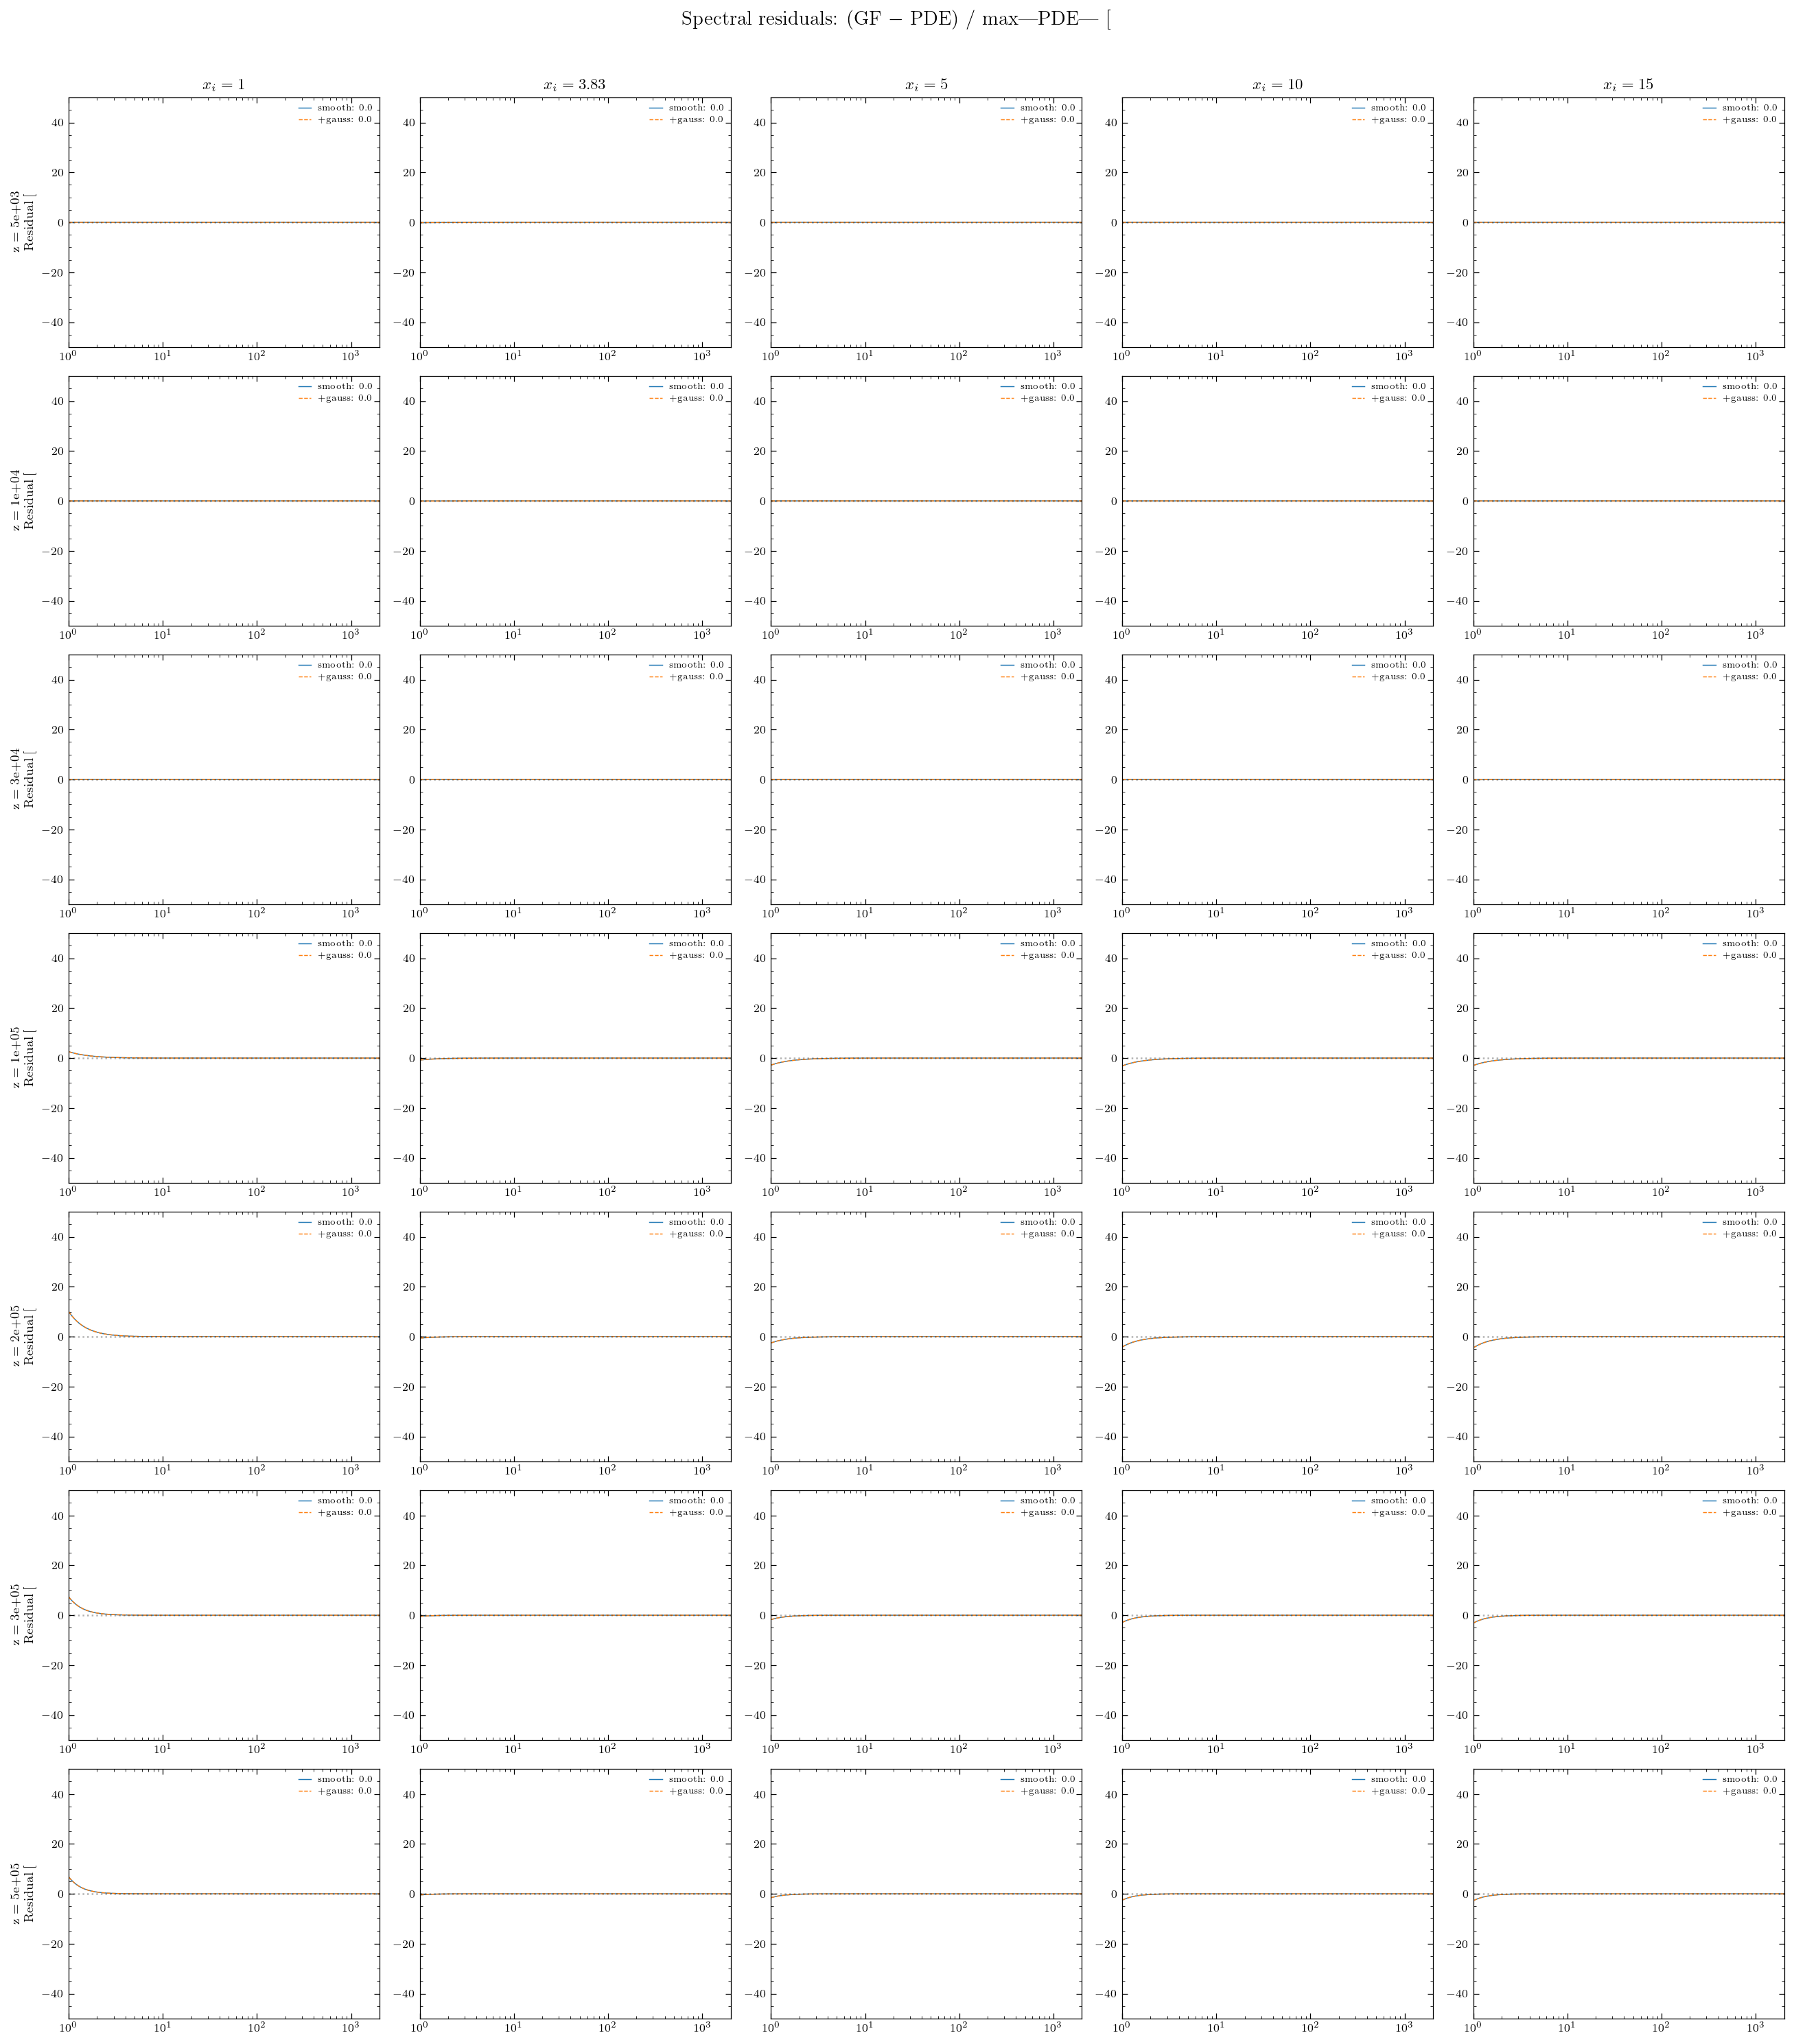

Regime   x_i        z   P_s  RMS smooth RMS +gauss  RMS !bump
y       1.00    5e+03  0.93        0.0%        0.0%        0.0%
y       3.83    5e+03  0.98        0.0%        0.0%        0.0%
y       5.00    5e+03  0.99        0.0%        0.0%        0.0%
y      10.00    5e+03  0.99        0.0%        0.0%        0.0%
y      15.00    5e+03  1.00        0.0%        0.0%        0.0%
y       1.00    1e+04  0.96        0.0%        0.0%        0.0%
y       3.83    1e+04  0.99        0.0%        0.0%        0.0%
y       5.00    1e+04  0.99        0.0%        0.0%        0.0%
y      10.00    1e+04  1.00        0.0%        0.0%        0.0%
y      15.00    1e+04  1.00        0.0%        0.0%        0.0%
y       1.00    3e+04  0.98        0.0%        0.0%        0.0%
y       3.83    3e+04  0.99        0.0%        0.0%        0.0%
y       5.00    3e+04  1.00        0.0%        0.0%        0.0%
y      10.00    3e+04  1.00        0.0%        0.0%        0.0%
y      15.00    3e+04  1.00        0.0%   

In [ ]:
def spectral_residual(x_pde, dn_pde, x_inj, z_h, sigma_x=0.0,
                       x_exclude_radius=0.0, signal_thresh=0.01):
    """Compute (GF - PDE) / max|PDE| residual."""
    gf = greens_function_photon(x_pde, x_inj, z_h, sigma_x=sigma_x, number_conserving=False)
    pde = dn_pde / dn_over_n
    max_pde = np.max(np.abs(pde))
    if max_pde < 1e-40:
        return np.zeros_like(x_pde), 0.0, 0.0
    res = (gf - pde) / max_pde
    mask = (np.abs(pde) > signal_thresh * max_pde) & (x_pde > 0.3) & (x_pde < 35)
    if x_exclude_radius > 0:
        mask &= np.abs(x_pde - x_inj) > x_exclude_radius
    rms = np.sqrt(np.mean(res[mask]**2)) if mask.sum() > 3 else 0.0
    max_err = np.max(np.abs(res[mask])) if mask.sum() > 3 else 0.0
    return res, rms, max_err

# Same grid layout as spectral comparison
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 2.8*nrows), squeeze=False)

summary = []
for ri, z_i in enumerate(z_avail):
    for ci, x_i in enumerate(x_avail):
        ax = axes[ri][ci]
        if (x_i, z_i) not in pde_spectra:
            ax.set_visible(False)
            continue

        x_pde, dn_pde, _, _ = pde_spectra[(x_i, z_i)]
        nu_pde = x_pde / X_PER_GHZ

        sx = default_sigma_x(x_i)
        res0, rms0, _ = spectral_residual(x_pde, dn_pde, x_i, z_i, sigma_x=0.0)
        res_sx, rms_sx, _ = spectral_residual(x_pde, dn_pde, x_i, z_i, sigma_x=sx)
        # RMS excluding the bump region (smooth spectrum only)
        _, rms_nb, _ = spectral_residual(x_pde, dn_pde, x_i, z_i, sigma_x=sx,
                                         x_exclude_radius=max(1.0, 0.3*x_i))

        pm = (nu_pde > 1) & (nu_pde < 2000)
        ax.plot(nu_pde[pm], res0[pm]*100, 'C0-', lw=0.7, label=f'smooth: {rms0*100:.1f}%')
        ax.plot(nu_pde[pm], res_sx[pm]*100, 'C1--', lw=0.7,
                label=f'+gauss: {rms_sx*100:.1f}%')
        ax.axhline(0, color='k', ls=':', alpha=0.3)
        ax.set_xscale('log')
        ax.set_xlim(1, 2000)
        ax.set_ylim(-50, 50)  # clip to +/- 50%

        if ri == 0:
            ax.set_title(f'$x_i = {x_i}$', fontsize=11)
        if ci == 0:
            ax.set_ylabel(f'z = {z_i:.0e}\nResidual [%]', fontsize=9)
        ax.legend(fontsize=6, loc='best')

        regime = 'y' if z_i <= 3e4 else ('trans' if z_i <= 8e4 else 'mu')
        ps = float(photon_survival_probability(np.array([x_i]), z_i)[0])
        summary.append(dict(x_inj=x_i, z_h=z_i, regime=regime, P_s=ps,
                            rms_s0=rms0*100, rms_sx=rms_sx*100, rms_nb=rms_nb*100))

fig.suptitle('Spectral residuals: (GF $-$ PDE) / max|PDE| [%]', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/gf_pde_residual_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'Regime':<6} {'x_i':>5} {'z':>8} {'P_s':>5}  {'RMS smooth':>10} {'RMS +gauss':>10} {'RMS !bump':>10}")
print('=' * 68)
for s in sorted(summary, key=lambda r: (r['z_h'], r['x_inj'])):
    print(f"{s['regime']:<6} {s['x_inj']:>5.2f} {s['z_h']:>8.0e} {s['P_s']:>5.2f}  "
          f"{s['rms_s0']:>9.1f}%  {s['rms_sx']:>9.1f}%  {s['rms_nb']:>9.1f}%")

### Detailed comparison: spectrum overlay + residual for key cases

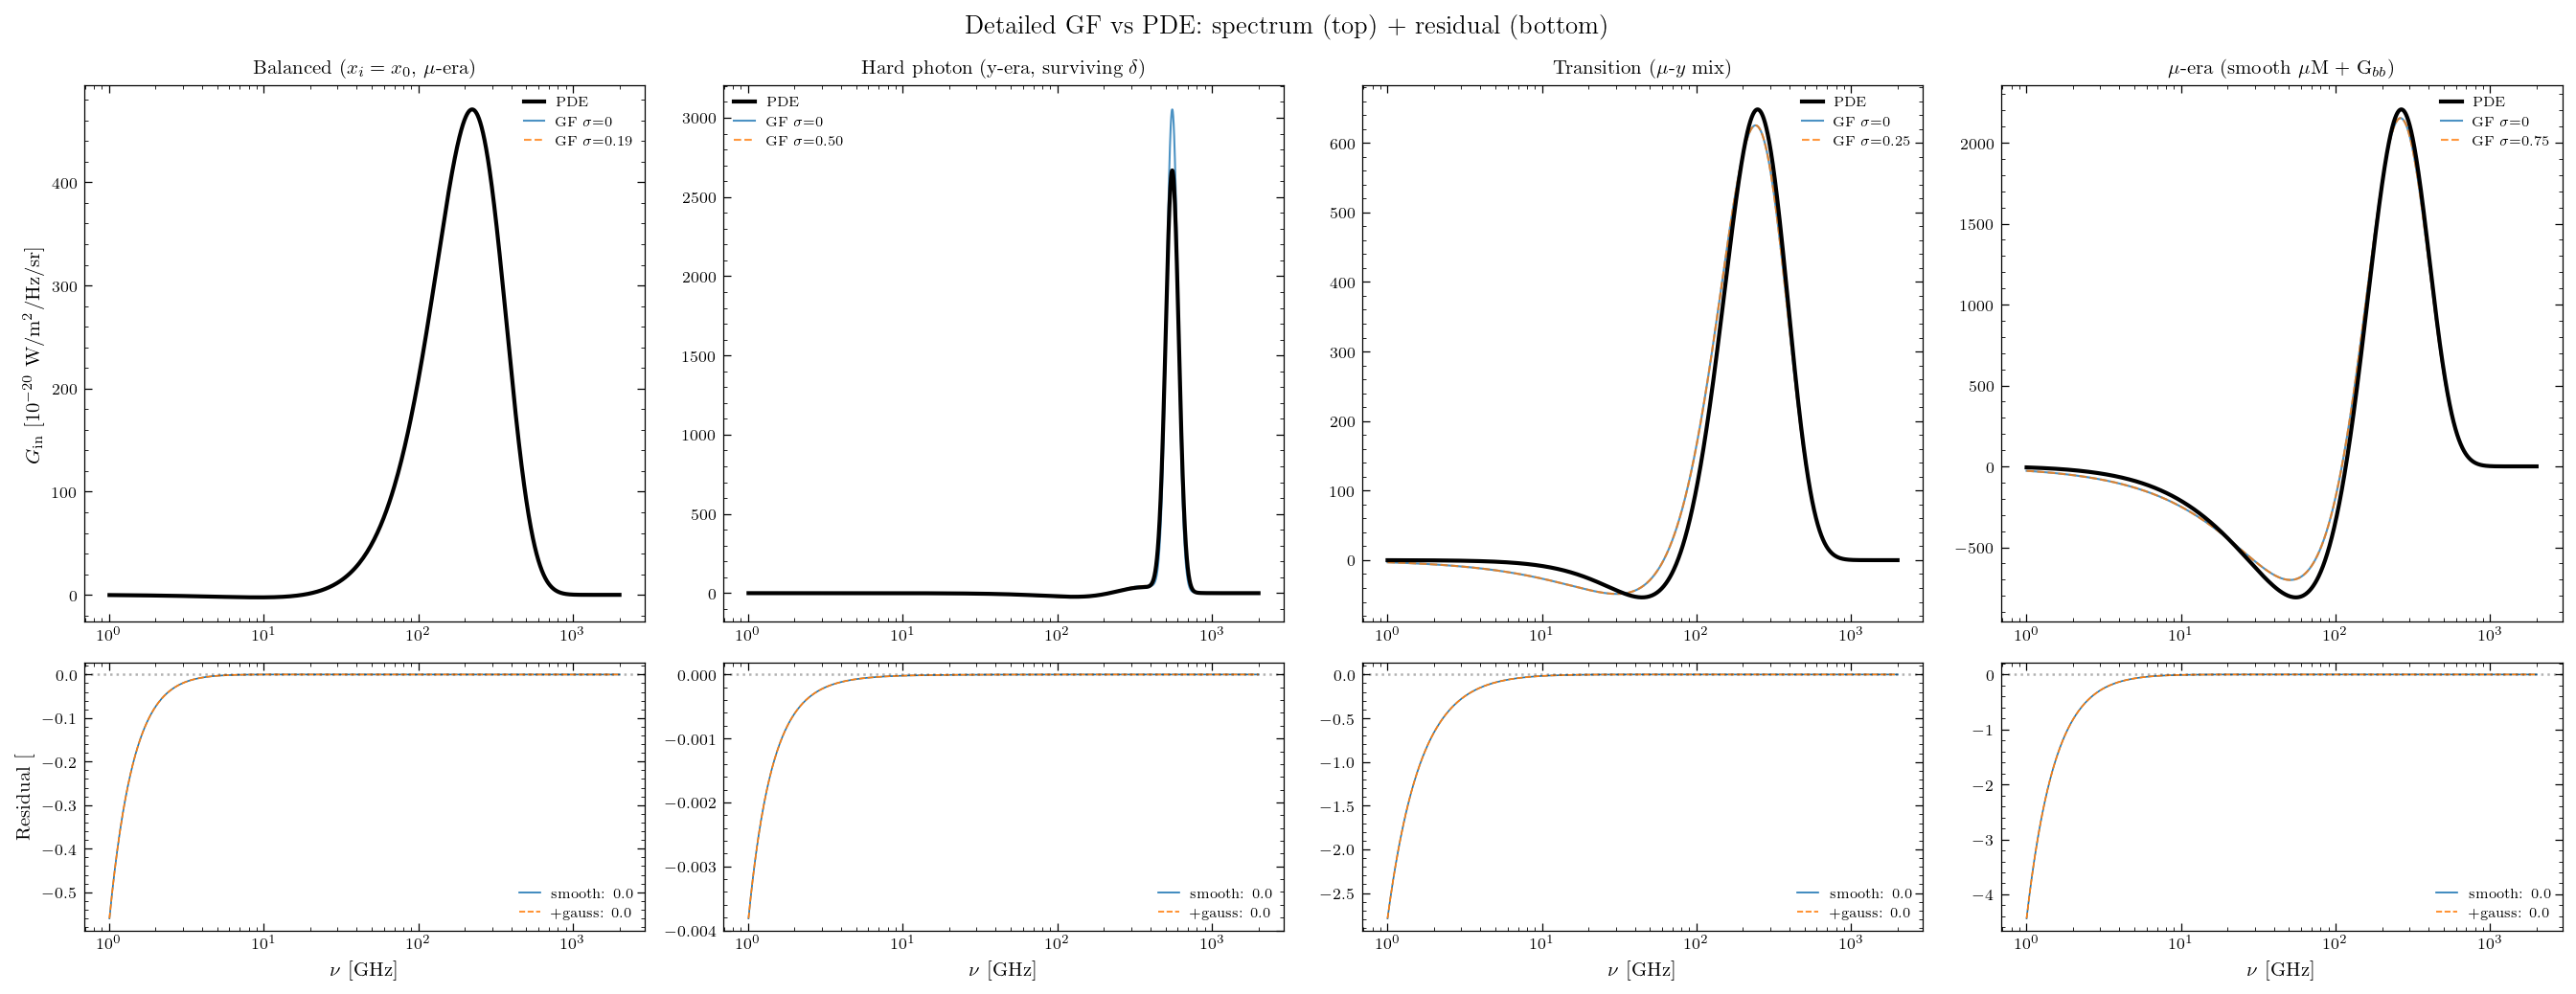

In [ ]:
# Detailed comparison: spectrum overlay (top) + residual (bottom)
key_cases = [
    (3.83, 2e5, r'Balanced ($x_i = x_0$, $\mu$-era)'),
    (10, 1e4, r'Hard photon (y-era, surviving $\delta$)'),
    (5, 1e5, r'Transition ($\mu$-$y$ mix)'),
    (15, 2e5, r'$\mu$-era (smooth $\mu$M + G$_{bb}$)'),
]
key_cases = [(x, z, t) for x, z, t in key_cases if (x, z) in pde_spectra]
nc = len(key_cases)

fig, axes = plt.subplots(2, nc, figsize=(4.5*nc, 7),
                          gridspec_kw={'height_ratios': [2, 1]})
if nc == 1:
    axes = axes.reshape(2, 1)

for col, (x_inj, z_h, title) in enumerate(key_cases):
    x_pde, dn_pde, _, _ = pde_spectra[(x_inj, z_h)]
    nu_pde = x_pde / X_PER_GHZ
    pde_norm = dn_pde / dn_over_n
    pde_I = dn_to_intensity_1e20(x_pde, pde_norm)

    sx = default_sigma_x(x_inj)
    gf0 = greens_function_photon(x_pde, x_inj, z_h, sigma_x=0.0, number_conserving=False)
    gf_sx = greens_function_photon(x_pde, x_inj, z_h, sigma_x=sx, number_conserving=False)
    gf0_I = dn_to_intensity_1e20(x_pde, gf0)
    gf_sx_I = dn_to_intensity_1e20(x_pde, gf_sx)

    pm = (nu_pde > 1) & (nu_pde < 2000)

    # Top: spectra
    ax = axes[0, col]
    ax.plot(nu_pde[pm], pde_I[pm], 'k-', lw=2, label='PDE', zorder=3)
    ax.plot(nu_pde[pm], gf0_I[pm], 'C0-', lw=1, alpha=0.8, label=r'GF $\sigma$=0')
    ax.plot(nu_pde[pm], gf_sx_I[pm], 'C1--', lw=1, alpha=0.8,
            label=rf'GF $\sigma$={sx:.2f}')
    ax.set_xscale('log')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    if col == 0:
        ax.set_ylabel(r'$G_\mathrm{in}$ [$10^{-20}$ W/m$^2$/Hz/sr]')

    # Bottom: residual
    ax = axes[1, col]
    res0, rms0, _ = spectral_residual(x_pde, dn_pde, x_inj, z_h, sigma_x=0.0)
    res_sx, rms_sx, _ = spectral_residual(x_pde, dn_pde, x_inj, z_h, sigma_x=sx)
    ax.plot(nu_pde[pm], res0[pm]*100, 'C0-', lw=0.8,
            label=f'smooth: {rms0*100:.1f}%')
    ax.plot(nu_pde[pm], res_sx[pm]*100, 'C1--', lw=0.8,
            label=f'+gauss: {rms_sx*100:.1f}%')
    ax.axhline(0, color='k', ls=':', alpha=0.3)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\nu$ [GHz]')
    if col == 0:
        ax.set_ylabel('Residual [%]')
    ax.legend(fontsize=7)

fig.suptitle('Detailed GF vs PDE: spectrum (top) + residual (bottom)', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/gf_pde_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

### Energy conservation check

$\Delta\rho/\rho = \int x^3 \Delta n\, dx \,/\, G_3$ should equal $\alpha_\rho x_i$ for both PDE and GF.

In [ ]:
print('=== Energy conservation: Drho/rho = integral(x^3 Dn dx) / G3 ===')
print(f"{'x_i':>6} {'z':>8} {'Target':>8} {'PDE':>10} {'GF s=0':>10} {'GF +gauss':>10} {'PDE err':>8} {'GF0 err':>8}")
print('=' * 86)

for x_inj, z_h in sorted(pde_spectra.keys(), key=lambda c: (c[1], c[0])):
    if not isinstance(z_h, (int, float)):
        continue  # skip tuple keys like (x_i, z_h, n_pts)
    x_pde, dn_pde, _, _ = pde_spectra[(x_inj, z_h)]
    pde_norm = dn_pde / dn_over_n
    drho_pde = np.trapz(x_pde**3 * pde_norm, x_pde) / G3_PLANCK

    sx = default_sigma_x(x_inj)
    gf0 = greens_function_photon(x_pde, x_inj, z_h, sigma_x=0.0, number_conserving=False)
    gf_sx = greens_function_photon(x_pde, x_inj, z_h, sigma_x=sx, number_conserving=False)
    drho_gf0 = np.trapz(x_pde**3 * gf0, x_pde) / G3_PLANCK
    drho_gf_sx = np.trapz(x_pde**3 * gf_sx, x_pde) / G3_PLANCK

    target = ALPHA_RHO * x_inj
    pde_err = (drho_pde / target - 1) * 100 if abs(target) > 1e-20 else 0
    gf0_err = (drho_gf0 / target - 1) * 100 if abs(target) > 1e-20 else 0

    print(f'{x_inj:>6.2f} {z_h:>8.0e} {target:>8.4f} {drho_pde:>10.4f} {drho_gf0:>10.4f} '
          f'{drho_gf_sx:>10.4f} {pde_err:>+7.1f}% {gf0_err:>+7.1f}%')

=== Energy conservation: Drho/rho = integral(x^3 Dn dx) / G3 ===
   x_i        z   Target        PDE     GF s=0  GF +gauss  PDE err  GF0 err
  0.00    5e+03   0.0004     0.0004     0.0004     0.0004    +0.0%    +0.0%
  0.01    5e+03   0.0037     0.0037     0.0037     0.0037    +0.0%    +0.0%
  1.00    5e+03   0.3702     0.3702     0.3702     0.3706    -0.0%    +0.0%
  3.83    5e+03   1.4179     1.4179     1.4179     1.4196    +0.0%    +0.0%
  5.00    5e+03   1.8510     1.8510     1.8510     1.8533    +0.0%    +0.0%
 10.00    5e+03   3.7021     3.7021     3.7021     3.7067    +0.0%    -0.0%
 15.00    5e+03   5.5531     5.5531     5.5531     5.5600    +0.0%    -0.0%
  0.00    1e+04   0.0004     0.0004     0.0004     0.0004    +0.0%    +0.0%
  0.01    1e+04   0.0037     0.0037     0.0037     0.0037    -0.0%    +0.0%
  1.00    1e+04   0.3702     0.3702     0.3702     0.3707    -0.0%    +0.0%
  3.83    1e+04   1.4179     1.4179     1.4179     1.4197    -0.0%    +0.0%
  5.00    1e+04   1.851

/tmp/ipykernel_32622/4076234168.py:13: UserWarning: x_inj=1.00e-03: DC/BR absorption extremely strong at this frequency; survival probability ~ 0.
  gf0 = greens_function_photon(x_pde, x_inj, z_h, sigma_x=0.0, number_conserving=False)
/tmp/ipykernel_32622/4076234168.py:14: UserWarning: x_inj=1.00e-03: DC/BR absorption extremely strong at this frequency; survival probability ~ 0.
  gf_sx = greens_function_photon(x_pde, x_inj, z_h, sigma_x=sx, number_conserving=False)


## Summary

### GF accuracy by regime

| Regime | GF accuracy (smooth part) | Notes |
|--------|---------------------------|-------|
| $P_s \to 0$ (analytical) | **< $10^{-10}$** | Exact by construction |
| Balanced ($x_i \approx x_0$), $\mu$-era | **< 1%** | $\mu_\text{factor} \approx 0$, GF reduces to temperature shift |
| $\mu$-era ($z > 2\times10^5$), $x_i > 1$ | **3-12%** | Similar to standard energy-injection GF |
| Deep $\mu$ ($z = 2\times10^6$) | **4-12%** | Requires 4000 grid points for PDE convergence |
| Transition ($z \sim 10^5$) | **10-30%** | 3-component decomposition inherently limited |
| $y$-era ($z < 3\times10^4$), surviving photon | **Order-of-magnitude** | GF captures bump via Gaussian, but Compton broadening differs |

### Key findings

1. **Grid resolution critical at high $z$**: At $z > 10^6$, the PDE solver needs $\geq 4000$ grid
   points to resolve DC/BR processes at low frequencies. With only 1000 points, DC/BR emission
   is under-resolved, causing $\sim 2\times$ overshoot in $\mu$. The `run_pde_photon` function
   now auto-selects grid resolution: 4000 pts for $z > 10^6$, 2000 for $z > 5\times10^5$,
   1000 otherwise.

2. **$\sigma_x$ matters for PDE**: The default `sigma_x=0.3` was far too wide for $x_i < 1$,
   causing energy normalization errors up to 13$\times$. Fixed to `sigma_x = 0.05 \times x_i$.

3. **GF smooth ($\sigma_x = 0$) does NOT conserve energy** in the y-era: the missing
   $P_s \times \alpha_x$ fraction is the surviving photon $\delta$-function. This is correct
   behavior, not a bug.

4. **$\mu$-era agreement is 3-12%**: comparable to the standard heat-injection Green's function.
   Large fractional errors near spectral zero crossings are physically unimportant (small absolute signal).

5. **$x_i < 1$ not reliably testable via PDE**: The $G_2/x^2$ divergence at low $x$ makes
   the Gaussian source poorly normalized on finite grids.

### Known limitations

- **Transition era**: The 3-component ($\mu$ + $y$ + $T$-shift) decomposition cannot capture
  the intermediate spectral shapes that arise during $\mu \to y$ transition.
- **Surviving photon bump shape**: In the y-era, the PDE evolves the Gaussian source via
  Compton scattering, broadening and shifting it. The GF approximates this as an undistorted
  Gaussian plus a smooth $Y_\text{SZ}$ component — a simplification that breaks down for
  large Compton-$y$ parameter.